# AirBnB
https://insideairbnb.com/get-the-data/

https://data.insideairbnb.com/brazil/rj/rio-de-janeiro/2025-12-28/data/listings.csv.gz

In [3]:
import pandas as pd

In [4]:
# df = pd.read_csv('https://data.insideairbnb.com/the-netherlands/north-holland/amsterdam/2025-09-11/data/listings.csv.gz')
# df = pd.read_csv('https://data.insideairbnb.com/united-states/il/chicago/2025-09-22/data/listings.csv.gz')
df = pd.read_csv('https://data.insideairbnb.com/united-kingdom/england/london/2025-09-14/data/listings.csv.gz')
# df = pd.read_csv('https://data.insideairbnb.com/united-states/ny/new-york-city/2026-04-14/data/listings.csv.gz')

In [5]:
df.head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,13913,https://www.airbnb.com/rooms/13913,20250914034649,2025-09-16,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,4.87,4.78,4.78,NaN,f,2,1,1,0,0.30
1,15400,https://www.airbnb.com/rooms/15400,20250914034649,2025-09-16,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302,...,4.84,4.93,4.74,NaN,f,1,1,0,0,0.51
2,17402,https://www.airbnb.com/rooms/17402,20250914034649,2025-09-16,city scrape,Very Central Modern 3-Bed/2 Bath By Oxford St W1,"You'll have a great time in this beautiful, cl...","Fitzrovia is a very desirable trendy, arty and...",https://a0.muscache.com/pictures/39d5309d-fba7...,67564,...,4.72,4.89,4.61,NaN,f,2,2,0,0,0.32


In [6]:
len(df)

96871

In [ ]:
df.room_type.value_counts()

0           Private room
1        Entire home/apt
2        Entire home/apt
3        Entire home/apt
4        Entire home/apt
              ...       
96866    Entire home/apt
96867    Entire home/apt
96868    Entire home/apt
96869       Private room
96870       Private room
Name: room_type, Length: 96871, dtype: str

In [8]:
col_interes = ['id', 'name', 'host_name', 'host_location', 'host_response_time', 'host_is_superhost', 'neighbourhood', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'number_of_reviews', 'number_of_reviews_l30d', 'review_scores_rating', 'instant_bookable']

room_trad = {'Entire home/apt': 'Todo o espaço',
             'Private room': 'Quarto privativo',
             'Shared room' : 'Quarto compartilhado'}

In [9]:
df_treatment = df[col_interes].copy()

In [10]:
df_treatment.head(3)

,id,name,host_name,host_location,host_response_time,host_is_superhost,neighbourhood,neighbourhood_cleansed,latitude,longitude,...,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,number_of_reviews_l30d,review_scores_rating,instant_bookable
0,13913,Holiday London DB Room Let-on going,Alina,"London, United Kingdom",within a few hours,t,Neighborhood highlights,Islington,51.56861,-0.11270,...,1,1.0,1.0,1.0,$70.00,1,55,1,4.85,f
1,15400,Bright Chelsea Apartment. Chelsea!,Philippa,"Royal Borough of Kensington and Chelsea, Unite...",NaN,f,Neighborhood highlights,Kensington and Chelsea,51.48780,-0.16813,...,2,1.0,1.0,1.0,$149.00,4,97,0,4.80,f
2,17402,Very Central Modern 3-Bed/2 Bath By Oxford St W1,Liz,"London, United Kingdom",within an hour,t,Neighborhood highlights,Westminster,51.52195,-0.14094,...,6,2.0,3.0,3.0,$411.00,3,56,0,4.77,f


In [11]:
df_treatment['room_type'] = df_treatment['room_type'].map(room_trad)

In [12]:
df_treatment.info()

<class 'pandas.DataFrame'>
RangeIndex: 96871 entries, 0 to 96870
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      96871 non-null  int64  
 1   name                    96871 non-null  str    
 2   host_name               96828 non-null  str    
 3   host_location           73100 non-null  str    
 4   host_response_time      65164 non-null  str    
 5   host_is_superhost       95105 non-null  str    
 6   neighbourhood           41209 non-null  str    
 7   neighbourhood_cleansed  96871 non-null  str    
 8   latitude                96871 non-null  float64
 9   longitude               96871 non-null  float64
 10  property_type           96871 non-null  str    
 11  room_type               96762 non-null  str    
 12  accommodates            96871 non-null  int64  
 13  bathrooms               62025 non-null  float64
 14  bedrooms                84096 non-null  float64
 

In [13]:
df.host_response_time.value_counts()

host_response_time
within an hour        43447
within a few hours    10683
within a day           6726
a few days or more     4308
Name: count, dtype: int64

In [14]:
df_treatment['price_cleaned'] = df_treatment['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [15]:
remap_boolean = {'t' :  True, 'f': False}
df_treatment['host_is_superhost'] = df_treatment['host_is_superhost'].replace(remap_boolean).astype(bool)
df_treatment['instant_bookable'] = df_treatment['instant_bookable'].replace(remap_boolean).astype(bool)

In [16]:
def get_marker_color(room_type):
    cores = {
        'Entire home/apt': 'red',
        'Private room': 'blue',
        'Shared room': 'green'
    }
    return cores.get(room_type, 'gray')

In [17]:
pd.set_option('display.max_rows', 10)

In [18]:
df_treatment.to_csv("AirBnBLimpo.csv")

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns 

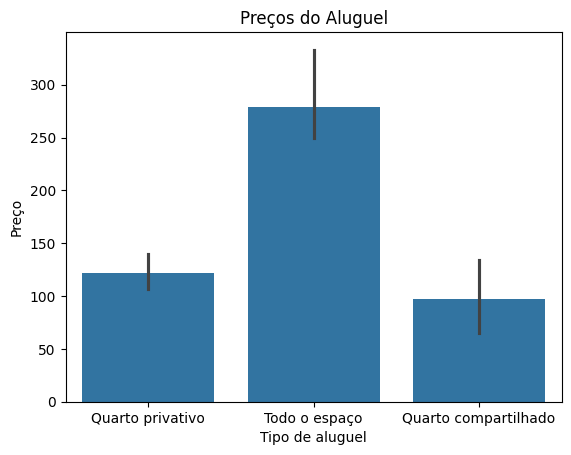

In [20]:
sns.barplot(df_treatment,
            x='room_type',
            y='price_cleaned')


plt.title('Preços do Aluguel')
plt.xlabel('Tipo de aluguel')
plt.ylabel('Preço')
plt.show()

- total host
- avg price
- avg number review
- total listing
- gráfico de total de alugueis por bairro e tipo de aluguel
- grafico de numero de reviews
- mapa dos locais
- seleção de rating


- treinar para obter rating?
- treinar para prever preço?

In [21]:
df_treatment.minimum_nights.describe()

count    96871.000000
mean         5.440297
std         23.686681
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max       1125.000000
Name: minimum_nights, dtype: float64

In [22]:
# df_treatment.bedrooms = df_treatment.bedrooms.fillna(df_treatment.bedrooms.median())
# df_treatment.beds = df_treatment.beds.fillna(df_treatment.beds.median())
# df_treatment.bathrooms = df_treatment.bathrooms.fillna(df_treatment.bathrooms.median())
# df_treatment.review_scores_rating = df_treatment.review_scores_rating.fillna(0)
df_treatment.host_response_time = df_treatment.host_response_time.fillna("Não informado")

In [23]:
df_treatment.info()

<class 'pandas.DataFrame'>
RangeIndex: 96871 entries, 0 to 96870
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      96871 non-null  int64  
 1   name                    96871 non-null  str    
 2   host_name               96828 non-null  str    
 3   host_location           73100 non-null  str    
 4   host_response_time      96871 non-null  str    
 5   host_is_superhost       96871 non-null  bool   
 6   neighbourhood           41209 non-null  str    
 7   neighbourhood_cleansed  96871 non-null  str    
 8   latitude                96871 non-null  float64
 9   longitude               96871 non-null  float64
 10  property_type           96871 non-null  str    
 11  room_type               96762 non-null  str    
 12  accommodates            96871 non-null  int64  
 13  bathrooms               62025 non-null  float64
 14  bedrooms                84096 non-null  float64
 

In [24]:
df_treatment.price_cleaned.describe()

count    6.196300e+04
mean     2.299170e+02
std      4.437589e+03
min      7.000000e+00
25%      7.700000e+01
50%      1.350000e+02
75%      2.210000e+02
max      1.085147e+06
Name: price_cleaned, dtype: float64

**💡 Evidência de Outliers nos Preços**

A distribuição dos preços apresenta fortes indícios de valores discrepantes (outliers):

- Média inflacionada: A média está em 4.388, enquanto o terceiro quartil (75%) é de apenas 565 (ou seja, 75% dos anúncios custam até 565).
- Alta dispersão: O desvio padrão supera o valor do próprio percentil de 75%, mostrando uma variação extrema.
- Máximo discrepante: O valor máximo está excessivamente alto em comparação com o restante dos dados.

Ação: Vamos realizar o corte (trimming) desses outliers acima de 565 para normalizar a análise.

In [25]:
df_treatment = df_treatment[df_treatment["price_cleaned"] <=1000] 
df_treatment.price_cleaned.describe()

count    61240.000000
mean       173.589549
std        145.780172
min          7.000000
25%         77.000000
50%        133.000000
75%        217.000000
max       1000.000000
Name: price_cleaned, dtype: float64

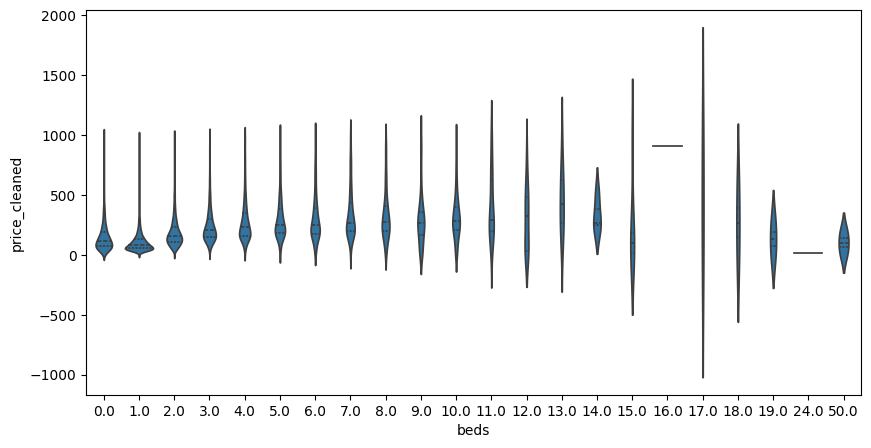

In [26]:
import seaborn as sns

plt.figure(figsize=[10,5])

ax = sns.violinplot(x="beds", y="price_cleaned", data=df_treatment, inner="quartiles")

# ax.set_yscale("log")
# plt.xlim(-0.25,2.5)

plt.show()


0 camas nos anuncios? Provavlemente algum erro dos anuncios, portanto vamos verificar a quantidade que isso ocorre, se o melhor a se fazer é limpar, ou arrumar automaticamente

In [27]:
print("A quantidade de quartos com 0 camas é:", len(df_treatment[df_treatment["beds"] == 0]))

print("A quantidade total de anuncios é:", len(df_treatment))

A quantidade de quartos com 0 camas é: 1351
A quantidade total de anuncios é: 61240


Pode ser limpo esses dados sem problemas na análise

In [28]:
df_treatment = df_treatment[df_treatment["beds"]>0]

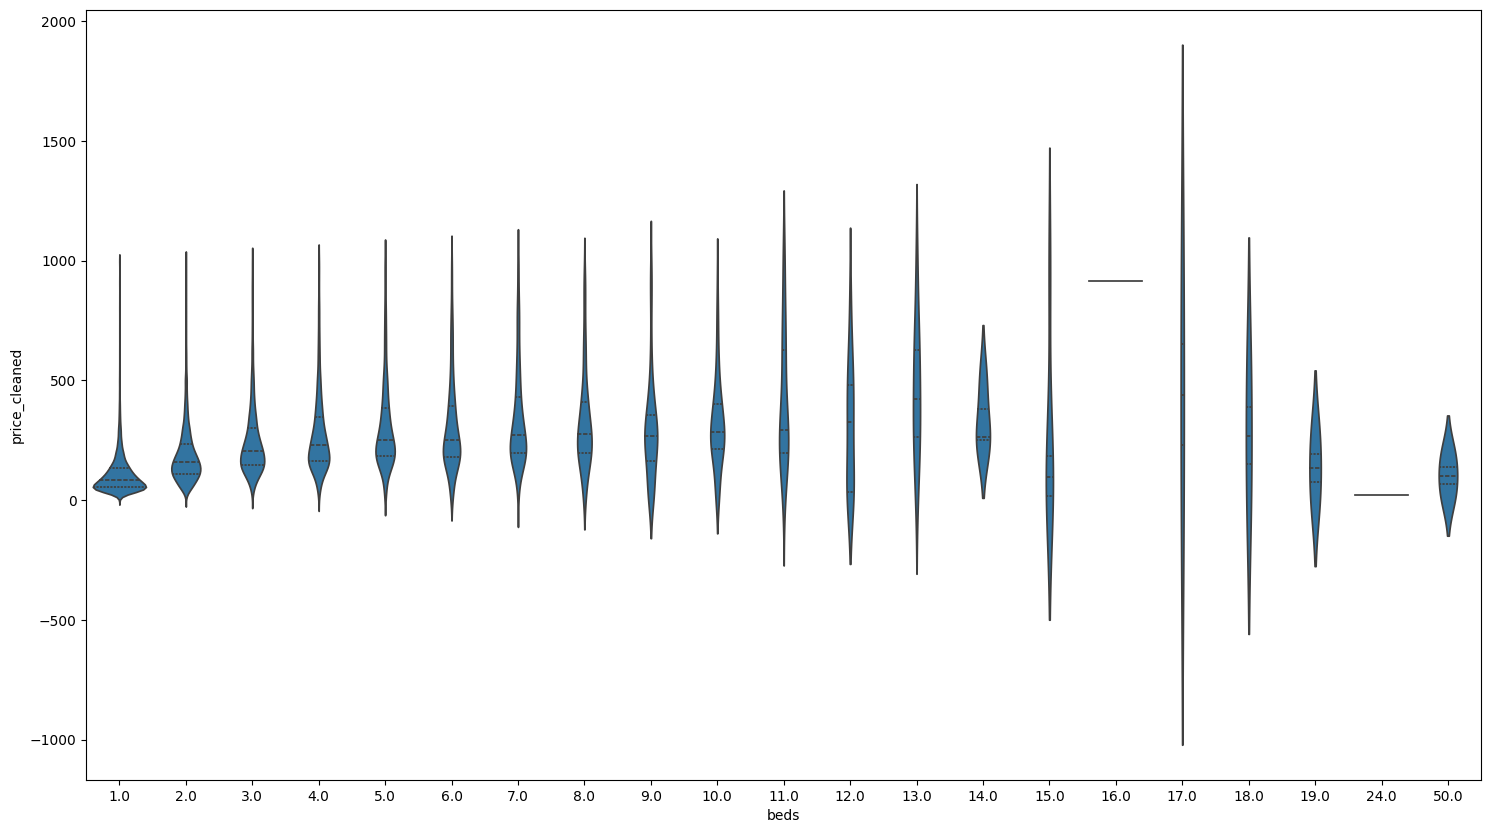

In [29]:
import seaborn as sns

plt.figure(figsize=[18,10])

ax = sns.violinplot(x="beds", y="price_cleaned", data=df_treatment, inner="quartiles")

# ax.set_yscale("log")
# plt.xlim(.75,7.15)

plt.show()


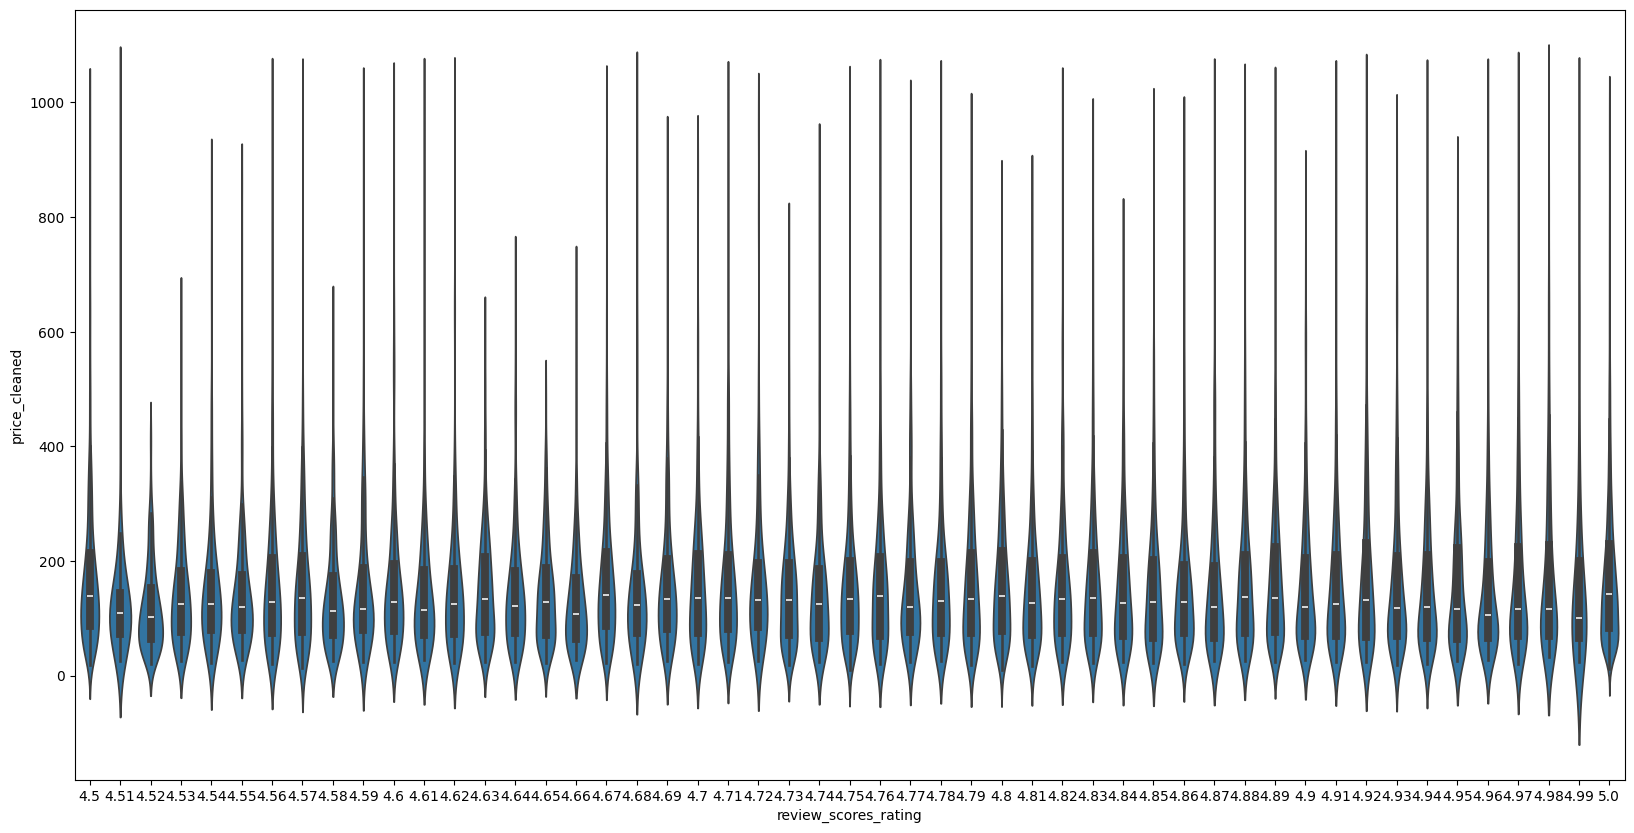

In [30]:
import seaborn as sns

plt.figure(figsize=[20,10])

df_plot_filtrado = df_treatment[
    df_treatment["review_scores_rating"].between(4.5, 5)
]

ax = sns.violinplot(x="review_scores_rating", y="price_cleaned", data=df_plot_filtrado)

# plt.xlim(4,5.1)

plt.show()


In [31]:
df_treatment.neighbourhood_cleansed.value_counts()

neighbourhood_cleansed
Westminster               8021
Kensington and Chelsea    4473
Camden                    4183
Tower Hamlets             4129
Southwark                 3132
                          ... 
Kingston upon Thames       475
Harrow                     447
Havering                   420
City of London             406
Sutton                     359
Name: count, Length: 33, dtype: int64

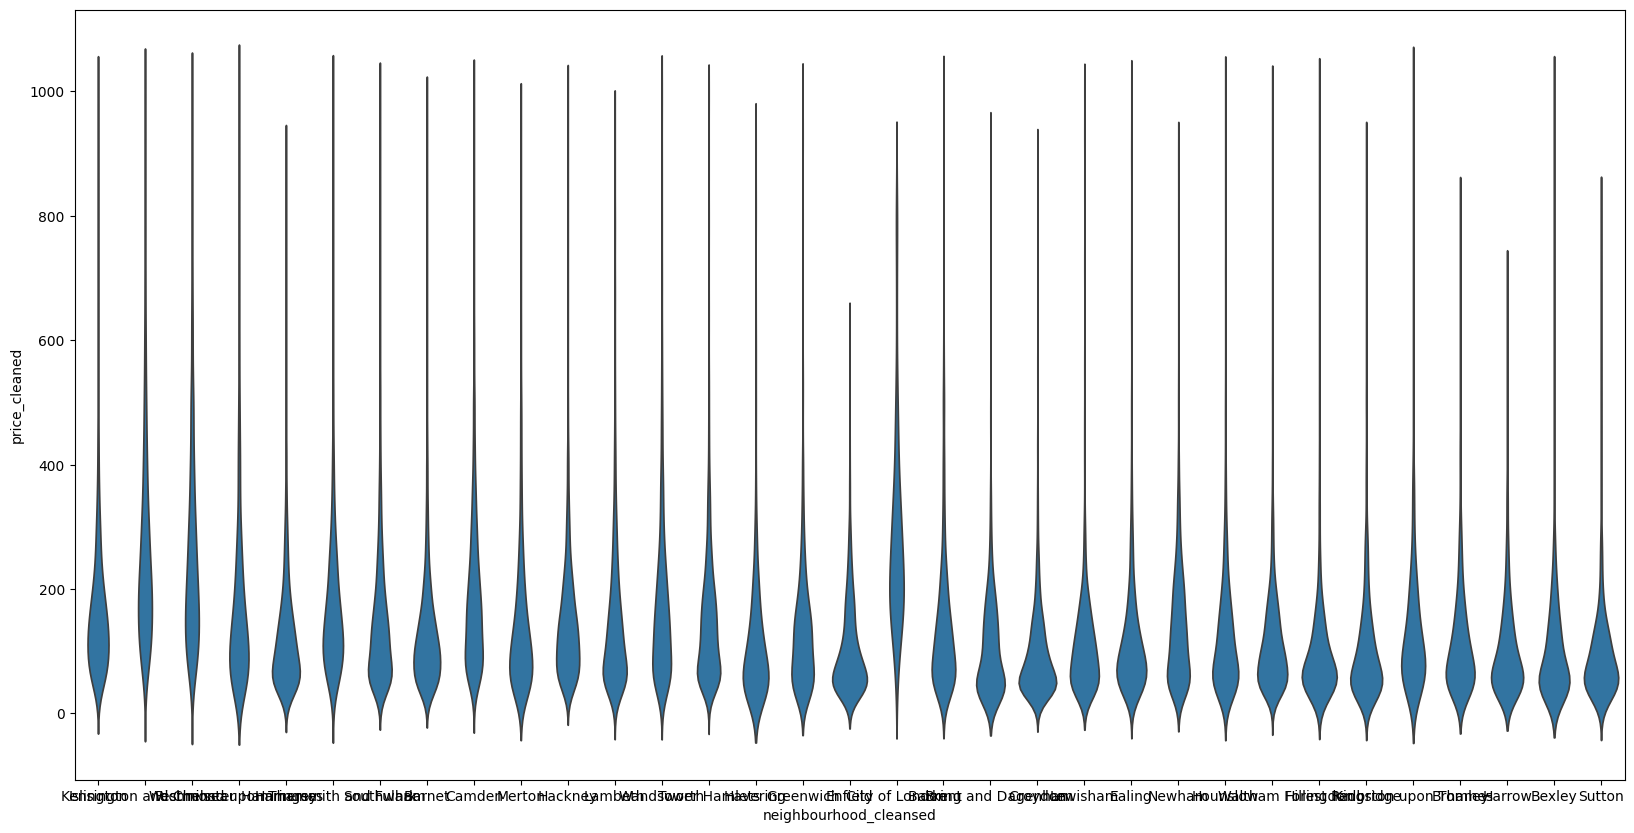

In [32]:
import seaborn as sns

plt.figure(figsize=[20,10])

ax = sns.violinplot(x="neighbourhood_cleansed", y="price_cleaned", data=df_treatment, inner=None)

# ax.set_yscale("log")

plt.show()


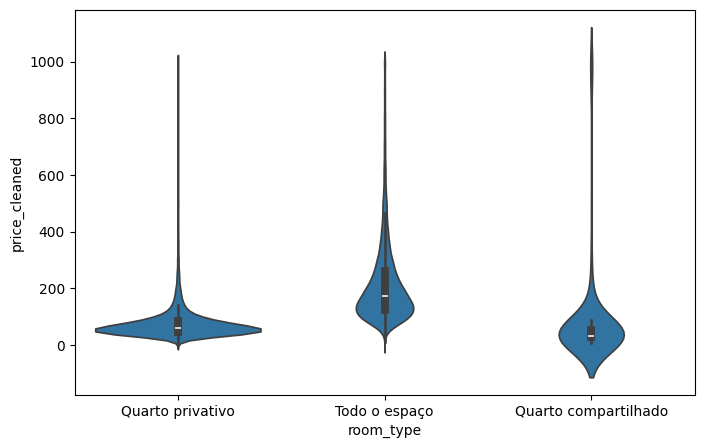

In [33]:
plt.figure(figsize=[8,5])

ax = sns.violinplot(df_treatment, x='room_type', y='price_cleaned')

# ax.set_yscale("log")
# plt.xlim(-0.25,2.5)

plt.show()

## Regressão sem Cuidado de Bairros ou Tipo de Quartos


### DecisionTree

In [34]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import SGDRegressor, Lasso
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import preprocessing
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.base import clone
import numpy as np
import plotly.express as px
RANDOM_SEED = 42

df_arvore_regressora = df_treatment[[
    'id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'price_cleaned',
    'room_type', 'review_scores_rating'
    ]].copy()

df_arvore_regressora.dropna(inplace=True)

Primeiro vamos tratar separando os room types

In [35]:
df_arvore_regressora.room_type.value_counts()

room_type
Todo o espaço           32178
Quarto privativo        14188
Quarto compartilhado      112
Name: count, dtype: int64

In [36]:
enc = preprocessing.OneHotEncoder()
enc.fit(df_arvore_regressora[['room_type']])
one_hot = enc.transform(df_arvore_regressora[['room_type']]).toarray()
df_arvore_regressora[['Quarto compartilhado', 'Quarto privativo', 'Todo o espaço']] = one_hot
# enc.categories_

Text(0.5, 1.0, 'Correlation Heatmap')

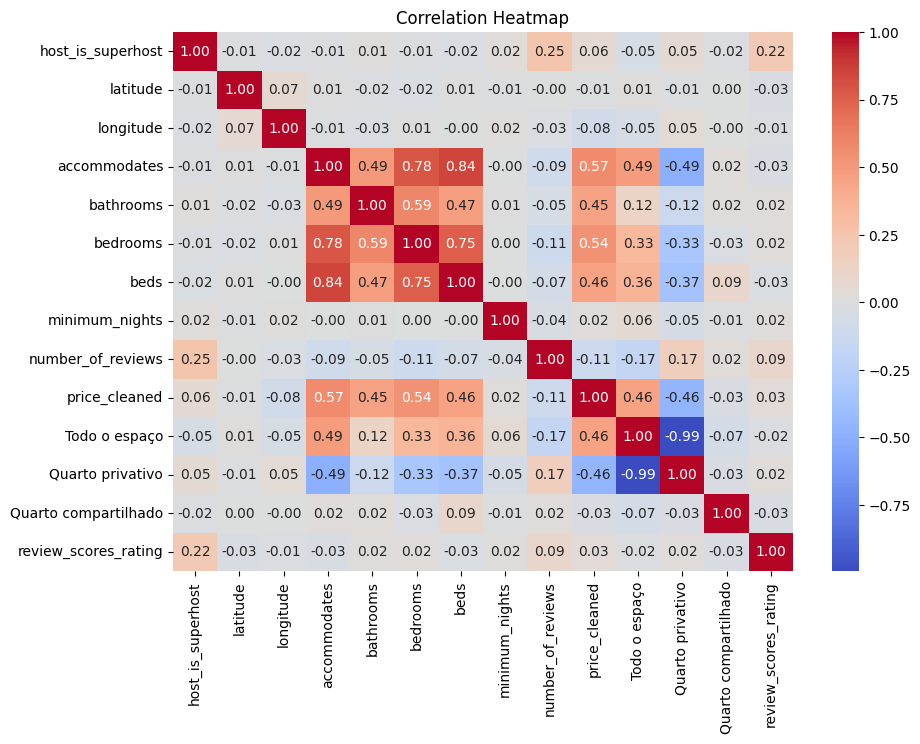

In [37]:
corr = df_arvore_regressora[[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'price_cleaned', 
    'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado', 'review_scores_rating'
]].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

In [38]:
cat_cols = ['host_is_superhost', 'instant_bookable', 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']

In [39]:
X = df_arvore_regressora.drop(columns=['price_cleaned'])
y = df_arvore_regressora['price_cleaned'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [40]:
arvore_regressora = DecisionTreeRegressor(
    max_depth=6, 
    min_samples_leaf=100,
    random_state=RANDOM_SEED
    )

In [41]:
precomputador = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [42]:
pipeline_arvore = Pipeline(steps=[
    ('pre-processamento', precomputador),
    ('modelo', arvore_regressora)
])

In [43]:
pipeline_arvore.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre-processamento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [44]:
y_pred_arvore = pipeline_arvore.predict(X_test)

In [45]:
print("R² Score:", r2_score(y_test, y_pred_arvore))
print("Root mean squared error:", root_mean_squared_error(y_test,y_pred_arvore))

R² Score: 0.4748352835819132
Root mean squared error: 96.69639201545513


In [46]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)


print("R² Score do Dummy (Média):", r2_score(y_test, pred_dummy))
print(f"RMSE do Dummy (Média): {root_mean_squared_error(y_test, pred_dummy):.2f}")

R² Score do Dummy (Média): -4.835836951100347e-06
RMSE do Dummy (Média): 133.43


Ou seja, nosso modelo está realmente tendo algum efeito quando comparado com a média, está performando melhor que sem um modelo

In [47]:
df_resultados_arvore = pd.DataFrame({
    'id_imovel': X_test['id'],       # Busca o ID original que ficou de fora do treino
    'preço_real': y_test,             # A nota real (Target)
    'preço_previsto': y_pred_arvore      # A nota que a árvore calculou
})
df_resultados_arvore.reset_index(drop=True, inplace=True)
df_resultados_arvore['erro'] = (df_resultados_arvore['preço_real'] - df_resultados_arvore['preço_previsto']).abs() / df_resultados_arvore['preço_real'] 


fig = px.line(df_resultados_arvore, y=['preço_real', 'preço_previsto'])
fig.show()
print(df_resultados_arvore[df_resultados_arvore['erro'] >=0.1].head())

             id_imovel  preço_real  preço_previsto      erro
0  1274569992149081020        92.0      255.808440  1.780527
1             19775854       134.0      103.950820  0.224248
2  1298449019321577357       115.0      156.625931  0.361965
3   943481379180819866       104.0      128.048040  0.231231
4  1222872165724786458       456.0      291.115637  0.361589


### Regressão linear

Acredito que a arvore de decisão vai lidar melhor com esse tipo de dados, mas vamos testar com regressões lineares e robust scaler

In [48]:
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
RANDOM_SEED = 42

df_lasso = df_treatment[[
    'id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'price_cleaned',
    'room_type', 'review_scores_rating'
    ]].copy()

df_lasso.dropna(inplace=True)

In [49]:
enc = preprocessing.OneHotEncoder()
enc.fit(df_lasso[['room_type']])
one_hot = enc.transform(df_lasso[['room_type']]).toarray()
df_lasso[['Quarto compartilhado', 'Quarto privativo', 'Todo o espaço']] = one_hot

In [50]:
cat_cols = ['host_is_superhost',  'instant_bookable', 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']

In [51]:
X = df_lasso.drop(columns=['price_cleaned'])
y = df_lasso['price_cleaned'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [52]:
precomputador = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False), cat_cols)
    ],
    remainder='drop'
)

pipeline_lasso = Pipeline(steps=[
    ('pre-processamento', precomputador),
    
    ('polinomial', PolynomialFeatures(degree=1, include_bias=False)),
    
    ('modelo', Lasso(alpha=0.0001, max_iter=5000))
])

pipeline_lasso.fit(X_train, y_train)

y_pred_lasso = pipeline_lasso.predict(X_test)

In [53]:
print("R² Score:", r2_score(y_test, y_pred_lasso))
print("Root mean squared error:", root_mean_squared_error(y_test,y_pred_lasso))

R² Score: 0.43706239196450913
Root mean squared error: 100.1134969511769


In [54]:
df_lasso = pd.DataFrame({
    'id_imovel': X_test['id'],       # Busca o ID original que ficou de fora do treino
    'preço_real': y_test,             # A nota real (Target)
    'preço_previsto': y_pred_lasso      # A nota que a árvore calculou
})
df_lasso.reset_index(drop=True, inplace=True)
df_lasso['erro'] = (df_lasso['preço_real'] - df_lasso['preço_previsto']).abs() / df_lasso['preço_real'] 


fig = px.line(df_lasso, y=['preço_real', 'preço_previsto'])
fig.show()
print(df_lasso[df_lasso['erro'] >=0.1].head())

             id_imovel  preço_real  preço_previsto      erro
0  1274569992149081020        92.0      254.198162  1.763024
1             19775854       134.0       80.848619  0.396652
2  1298449019321577357       115.0      170.219634  0.480171
3   943481379180819866       104.0      146.903123  0.412530
4  1222872165724786458       456.0      305.410259  0.330241


## Regressão com Cuidado de Bairros ou Tipos de Quartos

### Bairros

In [55]:
# Cria um dicionário onde cada chave é o valor do grupo (0 ou 1) 
# e o valor é o DataFrame correspondente filtrado
colunas_desejadas = ['id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'price_cleaned', 'minimum_nights']


dfs_por_bairro = {
    nome_grupo: dados[colunas_desejadas].dropna()
    for nome_grupo, dados in df_treatment.groupby('neighbourhood_cleansed')
}

# Para acessar o DataFrame dos bairros perigosos:
# dfs_por_grupo[1]

In [56]:
# import seaborn as sns
# plt.figure(figsize=(10, 7))
# corr = dfs_por_bairro[0][[
#     'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
#     'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
#     'instant_bookable', 'price_cleaned', 'review_scores_rating'
#     # 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
#     ]].dropna().corr()

# sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
# plt.title('Correlation Heatmap')
# plt.show()

In [57]:
cat_cols = ['host_is_superhost']#, 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']
num_cols = ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']

#### Arvore

In [58]:
precomputador_arvore = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [59]:
modelos_por_bairro = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

predicoes_por_bairro = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

metricas_por_bairro = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

In [60]:
MODELO_ATUAL = "arvore_normal"

for nome_grupo, df_grupo in dfs_por_bairro.items():
    if len(df_grupo) > 100:
        print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
        
        df_grupo.dropna(inplace=True)
        
        X_grupo = df_grupo.drop(columns=['price_cleaned'])
        y_grupo = df_grupo['price_cleaned'].values
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
        )
        
        pipeline_atual = Pipeline(steps=[
            ('pre-processamento', precomputador_arvore),
            ('modelo', clone(arvore_regressora))
        ])
        
        pipeline_atual.fit(X_train, y_train)
        y_pred_arvore = pipeline_atual.predict(X_test)

        r2 = r2_score(y_test, y_pred_arvore)
        rmse = root_mean_squared_error(y_test, y_pred_arvore)
        print(f"R² Score: {r2:.4f}")
        print(f"Root mean squared error: {rmse:.4f}")
        
        modelos_por_bairro[MODELO_ATUAL][nome_grupo] = pipeline_atual
        
        predicoes_por_bairro[MODELO_ATUAL][nome_grupo] = {
            'y_test': y_test,
            'y_pred': y_pred_arvore
        }
        
        metricas_por_bairro[MODELO_ATUAL][nome_grupo] = {
            'R2': r2, 
            'RMSE': rmse
        }


--- Treinando arvore_normal para o grupo: Barking and Dagenham ---
R² Score: 0.3544
Root mean squared error: 89.9909

--- Treinando arvore_normal para o grupo: Barnet ---
R² Score: 0.5219
Root mean squared error: 65.5194

--- Treinando arvore_normal para o grupo: Bexley ---
R² Score: 0.3230
Root mean squared error: 43.7434

--- Treinando arvore_normal para o grupo: Brent ---
R² Score: 0.3665
Root mean squared error: 95.4584

--- Treinando arvore_normal para o grupo: Bromley ---
R² Score: 0.2798
Root mean squared error: 78.7402

--- Treinando arvore_normal para o grupo: Camden ---
R² Score: 0.5558
Root mean squared error: 81.5112

--- Treinando arvore_normal para o grupo: City of London ---
R² Score: 0.0966
Root mean squared error: 132.3124

--- Treinando arvore_normal para o grupo: Croydon ---
R² Score: 0.3824
Root mean squared error: 56.3795

--- Treinando arvore_normal para o grupo: Ealing ---
R² Score: 0.4324
Root mean squared error: 61.9064

--- Treinando arvore_normal para o grup

### Tipos de Quartos

In [61]:
colunas_desejadas = ['id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'price_cleaned', 'minimum_nights']

dfs_por_quartos = {
    nome_grupo: dados[colunas_desejadas].dropna() 
    for nome_grupo, dados in df_treatment.groupby('room_type')
}

In [62]:
df_treatment.room_type.value_counts()

room_type
Todo o espaço           40793
Quarto privativo        18725
Quarto compartilhado      185
Name: count, dtype: int64

In [63]:
room_trad.values()

dict_values(['Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'])

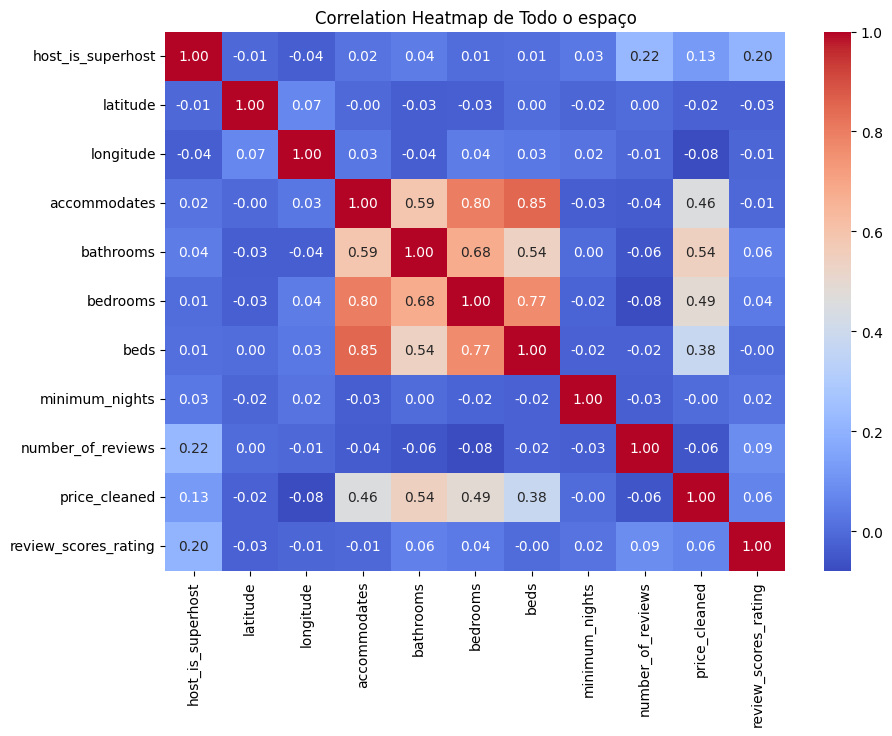

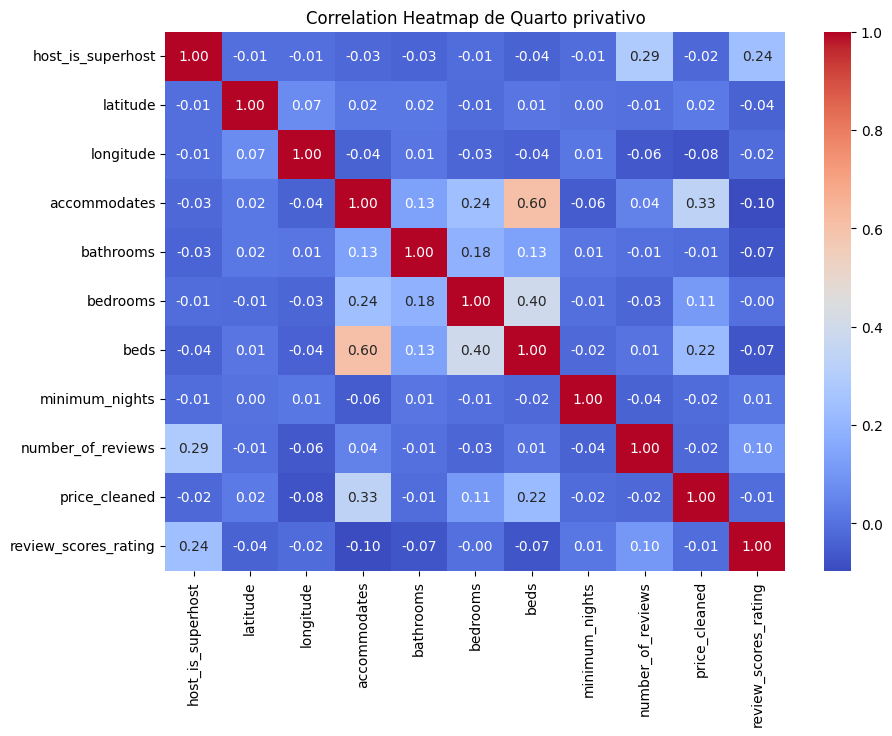

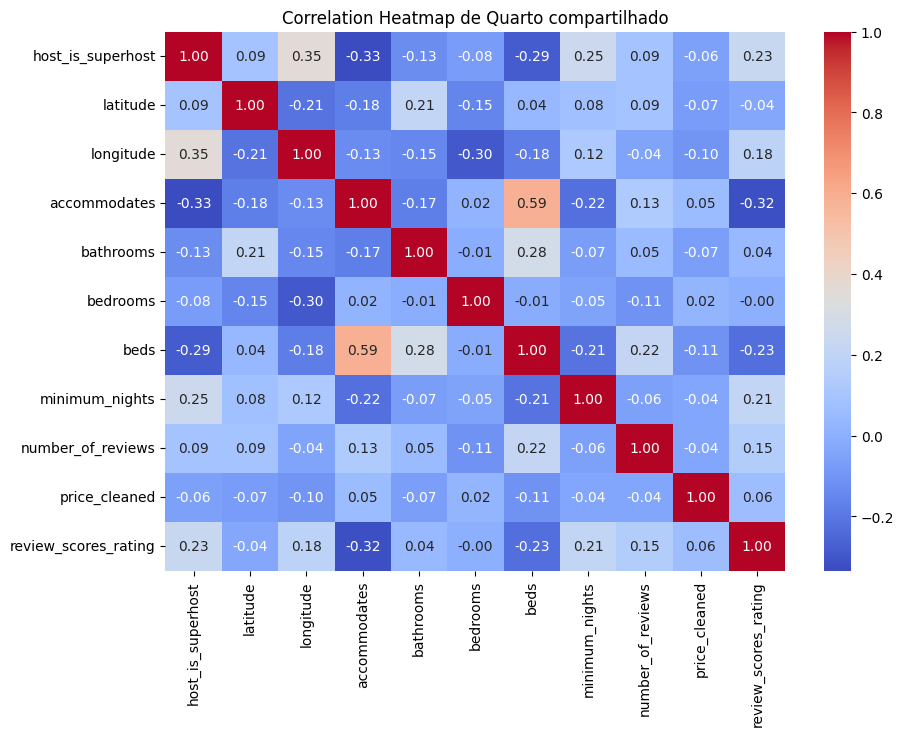

In [64]:
for room in room_trad.values():
    plt.figure(figsize=(10, 7))
    corr = dfs_por_quartos[room][[
        'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
        'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
        'price_cleaned', 'review_scores_rating'
        # 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
        ]].dropna().corr()

    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title(f'Correlation Heatmap de {room}' )
    plt.show()

#### Arvore

In [65]:
cat_cols = ['host_is_superhost']#, 'instant_bookable']
num_cols = ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']

In [66]:
precomputador_arvore = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [67]:
modelos_por_quarto = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

predicoes_por_quarto = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

metricas_por_quarto = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

In [68]:
MODELO_ATUAL = "arvore_normal"

for nome_grupo, df_grupo in dfs_por_quartos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['price_cleaned'])
    y_grupo = df_grupo['price_cleaned'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_arvore),
        ('modelo', clone(arvore_regressora))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_arvore = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_arvore)
    rmse = root_mean_squared_error(y_test, y_pred_arvore)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}")
    
    modelos_por_quarto[MODELO_ATUAL][nome_grupo] = pipeline_atual
    predicoes_por_quarto[MODELO_ATUAL][nome_grupo] = {
        'y_test': y_test,
        'y_pred': y_pred_arvore
    }
    metricas_por_quarto[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'RMSE': rmse}


--- Treinando arvore_normal para o grupo: Quarto compartilhado ---
R² Score: -0.0327
Root mean squared error: 261.5695

--- Treinando arvore_normal para o grupo: Quarto privativo ---
R² Score: 0.1727
Root mean squared error: 62.3102

--- Treinando arvore_normal para o grupo: Todo o espaço ---
R² Score: 0.4465
Root mean squared error: 103.7921


Leve piora comparado ao modelo analisando tudo e comparando com "Todo o espaço"

#### XGBoost

In [ ]:
from xgboost import XGBRegressor

MODELO_ATUAL = "arvore_xgboost"

for nome_grupo, df_grupo in dfs_por_quartos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['price_cleaned'])
    y_grupo = df_grupo['price_cleaned'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    precomputador_do_grupo = clone(precomputador_arvore)
    
    pipeline_xgb = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('modelo', XGBRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=RANDOM_SEED,
            n_jobs=-1
        ))
    ])
    
    pipeline_xgb.fit(X_train, y_train)
    y_pred_xgb = pipeline_xgb.predict(X_test)

    r2 = r2_score(y_test, y_pred_xgb)
    rmse = root_mean_squared_error(y_test, y_pred_xgb)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}\n")
    
    modelos_por_quarto[MODELO_ATUAL][nome_grupo] = pipeline_xgb
    predicoes_por_quarto[MODELO_ATUAL][nome_grupo] = {'y_test': y_test, 'y_pred': y_pred_xgb}
    metricas_por_quarto[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'RMSE': rmse}


--- Treinando arvore_xgboost para o grupo: Quarto compartilhado ---
R² Score: -0.1164
Root mean squared error: 271.9577


--- Treinando arvore_xgboost para o grupo: Quarto privativo ---
R² Score: 0.3092
Root mean squared error: 56.9375


--- Treinando arvore_xgboost para o grupo: Todo o espaço ---
R² Score: 0.5821
Root mean squared error: 90.1834



Resultado muito bom com XGBoost, principalmente para os dados de todo o espaço

In [70]:
import pandas as pd
import plotly.express as px

nome_do_grupo = 'Todo o espaço' 

y_real = predicoes_por_quarto['arvore_xgboost'][nome_do_grupo]['y_test']
y_previsto = predicoes_por_quarto['arvore_xgboost'][nome_do_grupo]['y_pred']

df_grupo_original = dfs_por_quartos[nome_do_grupo].dropna()
X_grupo = df_grupo_original.drop(columns=['price_cleaned'])
y_grupo = df_grupo_original['price_cleaned'].values

_, X_test_grupo, _, _ = train_test_split(
    X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
)

df_grupo = pd.DataFrame({
    'id_imovel': X_test_grupo['id'], 
    'preço_real': y_real,            
    'preço_previsto': y_previsto     
})

df_grupo.reset_index(drop=True, inplace=True)
df_grupo['erro'] = (df_grupo['preço_real'] - df_grupo['preço_previsto']).abs() / df_grupo['preço_real']

fig = px.line(df_grupo, y=['preço_real', 'preço_previsto'], 
              title=f"Preço Real vs Previsto - {nome_do_grupo}")
fig.update_layout(
    width=1500,
    height=800
)
fig.show()

print(f"Exemplos com erro >= 10% para {nome_do_grupo}:")
print(df_grupo[df_grupo['erro'] >= 0.1].head())

Exemplos com erro >= 10% para Todo o espaço:
             id_imovel  preço_real  preço_previsto      erro
0  1238383710045772002       700.0      251.772202  0.640325
1   854429777091224448       240.0      448.863434  0.870264
2             36552072       113.0      159.209198  0.408931
3   962881062059214196       132.0      152.781006  0.157432
4  1289765835880633302       104.0       93.465233  0.101296


#### Lasso

In [71]:
precomputador_lasso_quartos = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False), cat_cols)
    ],
    remainder='drop'
)

In [85]:
from sklearn.base import clone

MODELO_ATUAL = "lasso"

for nome_grupo, df_grupo in dfs_por_quartos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['price_cleaned'])
    y_grupo = df_grupo['price_cleaned'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    precomputador_do_grupo = clone(precomputador_lasso_quartos)
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('polinomial', PolynomialFeatures(degree=3, include_bias=False)),
        ('modelo', Lasso(alpha=0.89, max_iter=5000))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_lasso = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_lasso)
    rmse = root_mean_squared_error(y_test, y_pred_lasso)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}\n")
    
    modelos_por_quarto[MODELO_ATUAL][nome_grupo] = pipeline_atual
    predicoes_por_quarto[MODELO_ATUAL][nome_grupo] = {
        'y_test': y_test,
        'y_pred': y_pred_lasso
    }
    metricas_por_quarto[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'RMSE': rmse}


--- Treinando lasso para o grupo: Quarto compartilhado ---
R² Score: -2.3307
Root mean squared error: 469.7421


--- Treinando lasso para o grupo: Quarto privativo ---


/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.333e+05, tolerance: 2.740e+02
  model = cd_fast.enet_coordinate_descent(


R² Score: 0.2090
Root mean squared error: 60.9282


--- Treinando lasso para o grupo: Todo o espaço ---
R² Score: 0.4489
Root mean squared error: 103.5668



Modelos de lasso aqui se torna melhor que arvore regressora. $R^2_{Score}$ = 0.3342613615652218 em arvore sem separação de quartos.

Anuncios que se alugam todo o espaço esta prevendo melhor, provavelmente os outros ainda estão piorando a analise feita anteriormente, note ainda que quarto compartilhado é a pior predição de todas

In [73]:
for room in room_trad.values():
    df = dfs_por_quartos[room]
    print("O número de dados para o tipo de anúncio", room ,len(df))

O número de dados para o tipo de anúncio Todo o espaço 32178
O número de dados para o tipo de anúncio Quarto privativo 14188
O número de dados para o tipo de anúncio Quarto compartilhado 112


Talves o problema dos quartos compartilhados esteja na quantidade de dados, poucos para se tirar uma estatística concisa. O dataset tem apenas 77 dados no total. Ao dividir em treino e teste (80/20), o conjunto de teste tem apenas cerca de 15 imóveis.

In [74]:
dfs_por_quartos["Quarto compartilhado"].price_cleaned.describe()

count     112.000000
mean       82.651786
std       196.890591
min        20.000000
25%        27.750000
50%        33.000000
75%        47.250000
max      1000.000000
Name: price_cleaned, dtype: float64

In [ ]:
import pandas as pd
import plotly.express as px

nome_do_grupo = 'Todo o espaço' 

y_real = predicoes_por_quarto['lasso'][nome_do_grupo]['y_test']
y_previsto = predicoes_por_quarto['lasso'][nome_do_grupo]['y_pred']

df_grupo_original = dfs_por_quartos[nome_do_grupo].dropna()
X_grupo = df_grupo_original.drop(columns=['price_cleaned'])
y_grupo = df_grupo_original['price_cleaned'].values

_, X_test_grupo, _, _ = train_test_split(
    X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
)

df_grupo = pd.DataFrame({
    'id_imovel': X_test_grupo['id'], 
    'preço_real': y_real,            
    'preço_previsto': y_previsto     
})

df_grupo.reset_index(drop=True, inplace=True)
df_grupo['erro'] = (df_grupo['preço_real'] - df_grupo['preço_previsto']).abs() / df_grupo['preço_real']

fig = px.line(df_grupo, y=['preço_real', 'preço_previsto'], 
              title=f"Preço Real vs Previsto - {nome_do_grupo}")
fig.show()

print(f"Exemplos com erro >= 10% para {nome_do_grupo}:")
print(df_grupo[df_grupo['erro'] >= 0.1].head())

Exemplos com erro >= 10% para Todo o espaço:
             id_imovel  preço_real  preço_previsto      erro
0  1238383710045772002       700.0      371.691637  0.469012
1   854429777091224448       240.0      411.375024  0.714063
2             36552072       113.0      180.130858  0.594078
3   962881062059214196       132.0      190.902522  0.446231
4  1289765835880633302       104.0      133.743693  0.285997


In [76]:
room_trad.values()

dict_values(['Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'])

In [77]:
df_rating_pred = df_treatment.copy()
df_rating_pred = df_rating_pred.dropna(subset=['room_type'])

In [78]:
df_treatment.room_type.value_counts()

room_type
Todo o espaço           40793
Quarto privativo        18725
Quarto compartilhado      185
Name: count, dtype: int64

### Previsão de Rating

In [79]:
from sklearn.linear_model import SGDRegressor, Lasso
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import preprocessing
import numpy as np
RANDOM_SEED = 42

df_rating_pred = df_rating_pred.dropna()
df_copa = df_rating_pred[df_rating_pred['neighbourhood_cleansed'] == 'Copacabana']
X = df_rating_pred.drop(columns=['review_scores_rating'])
y = df_rating_pred['review_scores_rating'].values
# X = df_copa.drop(columns=['review_scores_rating'])
# y = df_copa['review_scores_rating'].values

In [80]:
X.room_type.value_counts()

room_type
Todo o espaço           11658
Quarto privativo         5201
Quarto compartilhado       34
Name: count, dtype: int64

In [81]:
enc = preprocessing.OneHotEncoder()
enc.fit(df_rating_pred[['room_type']])
# enc.categories_
one_hot = enc.transform(df_rating_pred[['room_type']]).toarray()
# one_hot = enc.transform(df_copa[['room_type']]).toarray()
X[['Quarto compartilhado', 'Quarto privativo', 'Todo o espaço']] = one_hot
cat_cols = ['host_is_superhost', 'bairro_perigoso', 'instant_bookable', 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'price_cleaned']

Text(0.5, 1.0, 'Correlation Heatmap')

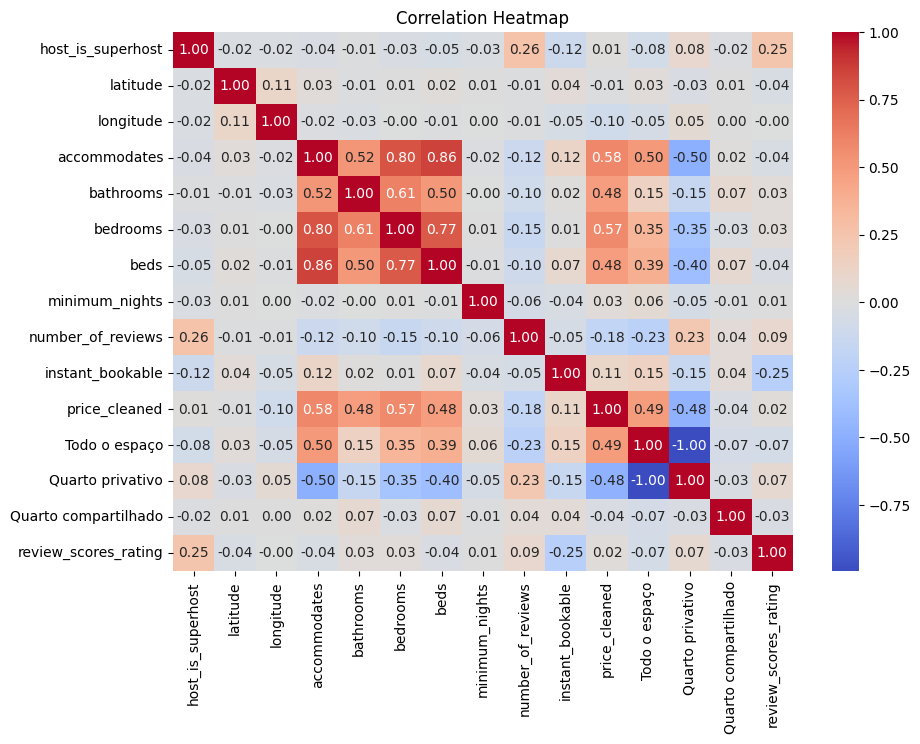

In [82]:
plt.figure(figsize=(10, 7))
X_com_y = X[[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'price_cleaned',
    'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
    ]].copy()

X_com_y['review_scores_rating'] = y

corr = X_com_y.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')